# LCS Historic Drift Detection

Detects **gradual trend/drift** in Laboratory Control Sample (`ANALYTICAL_TYPE == "Standard"`)
results, tracked **across jobs over time** rather than within a single analytical run.

This complements the existing job-scoped LCS tooling
(`LCS_drift_detection.ipynb` -> `LCS_drift_detectionV2.ipynb` -> `src/detectors/control_detector.py`),
which normalises and rolling-means whatever Standard rows exist in *one* `JOB_CODE` at a time.
A job-scoped view can never see a slow drift that plays out across weeks or months of separate
jobs, because each job starts a fresh rolling window. This notebook maintains a **persistent
historical dataset** per (`ANALYTE_CODE`, `STD_CODE`, `SCHEME_CODE`) group, and **simulates jobs
arriving one at a time in chronological order**: each job's analyte results get appended to their
own historical timeline and evaluated using only what was known before that job arrived, producing
a per-job report of "which analytes in this job need attention" -- point breach or predicted drift.

Two things worth knowing before reading the code:

- The trend/plot x-axis is **equal-step observation order**, not calendar time. Lab runs are
  irregular (a lab can go quiet for two weeks), and a calendar-time slope would make that gap
  look like the trend flattened out when nothing about the actual results changed. Two
  consecutive results register the same slope whether they were a second or two weeks apart.
- history is grouped by `(ANALYTE_CODE, STD_CODE, SCHEME_CODE)` -- see the notes at the bottom
  for why `SCHEME_CODE` matters and why `JOB_CODE` is not part of that grouping key.

See `C:\Users\Jurriaan\.claude\plans\i-want-you-to-linked-raven.md` for the full design rationale.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import theilslopes

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

In [3]:
# ── Paths ────────────────────────────────────────────────────────────────────
RAW_DATA_PATH = Path("../data/raw/ResultSet.csv")
HISTORY_PATH  = Path("../data/processed/lcs_standard_history.parquet")

# ── Grouping ─────────────────────────────────────────────────────────────────
# One independent historic time series = one (ANALYTE_CODE, STD_CODE, SCHEME_CODE)
# combination. STD_CODE (not STD_LOT_CODE) is the reference-material identity field
# -- verified STD_LOT_CODE=="Sample" is a labelling quirk of STD_CODE=="OREAS_502C",
# not a distinct category. SCHEME_CODE is required: the same ANALYTE_CODE/STD_CODE can
# carry different target/limit values under a different analytical scheme (verified:
# PB/OREAS_905 has different limits under GE_IMS40Q12 vs GE_ICP40Q12). JOB_CODE is
# deliberately excluded from the grouping key -- it identifies a single batch/run, not
# a recurring physical standard; instead, JOB_CODE drives the simulation loop below,
# with each job's own analytes appended to their own group's history in turn.
GROUP_KEYS = ["ANALYTE_CODE", "STD_CODE", "SCHEME_CODE"]

# Business key for de-duplicating observations across repeated pipeline runs.
DEDUP_KEYS = ["ANALYTE_CODE", "STD_CODE", "SCHEME_CODE", "JOB_CODE", "ANALYSED_DATE", "NUMERIC_FINAL_VALUE"]

# STD_CODE values that are not genuine reference-material identifiers
# (same exclusion list used by the parallel SRMS workflow, see notebooks/SRMS_LOGIC.md).
EXCLUDED_STD_CODES = {"", "nan", "Sample", "TSV_BLANK"}

# ── Historical window ────────────────────────────────────────────────────────
MAX_HISTORY_PER_ANALYTE = 30        # cap per group; most groups (median ~17 obs) never hit this
MAX_HISTORY_AGE_DAYS    = None      # optional extra cutoff; disabled by default (see design doc D)

MIN_HISTORY_POINT = 3               # below this: INSUFFICIENT_HISTORY, no trend attempted
MIN_HISTORY_TREND = 6               # below this (but >= MIN_HISTORY_POINT): trend computed at reduced confidence

# ── Trend detection ──────────────────────────────────────────────────────────
# Trend x-axis is equal-step OBSERVATION ORDER (0, 1, 2, ...), not elapsed calendar
# time -- see assign_sequence_position() below and the notebook header. TREND_SLOPE
# is therefore "transformed units per observation", not "per day".
TREND_WINDOW = 10                   # most recent valid observations used for the Theil-Sen fit
SLOPE_EPS = 1e-6                    # |slope| below this counts as FLAT, not UP/DOWN
TREND_STRENGTH_MIN_FOR_ESCALATION = 0.6   # min directional consistency to raise *_WARNING_DRIFT / show a projection
TREND_PROGRESS_MIN_FOR_FAILURE_DRIFT = 0.75  # fraction of the way to the warning bound needed to escalate to *_FAILURE_DRIFT

# ── Visualisation ─────────────────────────────────────────────────────────────
MAX_AUTO_PLOTS = 15                 # cap on inline auto-rendered plots per job report

In [4]:
# Columns validate_lcs_frame() requires to be present (as columns) before any
# row-level filtering; rows with nulls in the limit/date columns are dropped
# (not the whole run failing) -- see validate_lcs_frame().
REQUIRED_COLUMNS = [
    "ANALYTICAL_TYPE", "STD_CODE", "SCHEME_CODE", "ANALYTE_CODE",
    "ANALYSED_DATE", "NUMERIC_FINAL_VALUE",
    "INTERNAL_TARGET_VALUE", "INTERNAL_MAX_VALUE", "INTERNAL_MIN_VALUE",
    "INTERNAL_MAX_WARNING_VALUE", "INTERNAL_MIN_WARNING_VALUE",
]

# Columns persisted in the history store -- raw traceability columns plus the
# transformed value/limits computed at ingestion time (design doc J, question 19:
# both raw and transformed are stored, since raw is needed for display/audit and
# transformed avoids recomputing against possibly-since-changed limits).
HISTORY_COLUMNS = [
    "ANALYTE_CODE", "STD_CODE", "STD_LOT_CODE", "SCHEME_CODE", "JOB_CODE",
    "ANALYSED_DATE", "UNIT_CODE", "STANDARD_STATUS",
    "NUMERIC_FINAL_VALUE", "INTERNAL_TARGET_VALUE", "INTERNAL_MAX_VALUE", "INTERNAL_MIN_VALUE",
    "INTERNAL_MAX_WARNING_VALUE", "INTERNAL_MIN_WARNING_VALUE",
    "INTERNAL_MAX_INCLUSIVE", "INTERNAL_MIN_INCLUSIVE",
    "INTERNAL_MAX_WARNING_INCLUSIVE", "INTERNAL_MIN_WARNING_INCLUSIVE",
    "TRANSFORMED_VALUE", "TRANSFORMED_TARGET", "TRANSFORMED_MAX", "TRANSFORMED_MIN",
    "TRANSFORMED_MAX_WARNING", "TRANSFORMED_MIN_WARNING",
]


def _ensure_columns(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    """Return df restricted/reordered to `columns`, adding any missing ones as NA."""
    df = df.copy()
    for col in columns:
        if col not in df.columns:
            df[col] = pd.NA
    return df[columns]

In [5]:
def filter_standard_rows(df: pd.DataFrame, excluded_std_codes: set = EXCLUDED_STD_CODES) -> pd.DataFrame:
    """
    Restrict to ANALYTICAL_TYPE == "Standard" rows with a usable STD_CODE.

    Excludes STD_CODE values that are not genuine reference-material identifiers
    (blank, "Sample", "TSV_BLANK" -- see EXCLUDED_STD_CODES).
    """
    std_code = df["STD_CODE"].fillna("").astype(str).str.strip()
    mask = (df["ANALYTICAL_TYPE"] == "Standard") & (~std_code.isin(excluded_std_codes))
    return df.loc[mask].copy()


def validate_lcs_frame(df: pd.DataFrame) -> tuple:
    """
    Validate filtered Standard rows ahead of transformation.

    Checks REQUIRED_COLUMNS are present (raises if not), then drops rows with:
      - a missing ANALYSED_DATE,
      - a missing target or any limit value,
      - a zero-span limit (target == max or target == min -- would divide by zero),
      - a target outside [INTERNAL_MIN_VALUE, INTERNAL_MAX_VALUE] (data-entry error).

    Returns (clean_df, report) where `report` counts what was dropped and why,
    so data-quality issues stay visible on every run rather than silently vanishing.
    """
    missing_cols = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    report = {"n_input": len(df)}
    clean = df.copy()

    missing_date_mask = clean["ANALYSED_DATE"].isna()
    report["n_dropped_missing_date"] = int(missing_date_mask.sum())
    clean = clean.loc[~missing_date_mask]

    limit_cols = ["INTERNAL_TARGET_VALUE", "INTERNAL_MAX_VALUE", "INTERNAL_MIN_VALUE",
                  "INTERNAL_MAX_WARNING_VALUE", "INTERNAL_MIN_WARNING_VALUE"]
    missing_limits_mask = clean[limit_cols].isna().any(axis=1)
    report["n_dropped_missing_limits"] = int(missing_limits_mask.sum())
    clean = clean.loc[~missing_limits_mask]

    zero_span_mask = (
        (clean["INTERNAL_MAX_VALUE"] == clean["INTERNAL_TARGET_VALUE"]) |
        (clean["INTERNAL_TARGET_VALUE"] == clean["INTERNAL_MIN_VALUE"])
    )
    report["n_dropped_zero_span"] = int(zero_span_mask.sum())
    clean = clean.loc[~zero_span_mask]

    target_outside_mask = (
        (clean["INTERNAL_TARGET_VALUE"] > clean["INTERNAL_MAX_VALUE"]) |
        (clean["INTERNAL_TARGET_VALUE"] < clean["INTERNAL_MIN_VALUE"])
    )
    report["n_dropped_target_outside_range"] = int(target_outside_mask.sum())
    clean = clean.loc[~target_outside_mask].copy()

    report["n_output"] = len(clean)
    return clean, report

In [6]:
def transform_lcs_values(df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply the piecewise LCS transform: INTERNAL_TARGET_VALUE -> 0,
    INTERNAL_MAX_VALUE -> +1, INTERNAL_MIN_VALUE -> -1, computed per row using
    that row's OWN target/limits (not a group-level constant) so a limit change
    across history doesn't retroactively distort earlier points.

    A value on or above target is scaled by the upper span (max - target); a value
    below target is scaled by the lower span (target - min). The two spans are
    identical in the current export (verified across all 1,034 groups), but need
    not be in general -- see design doc B.5.

    Assumes `df` has already passed validate_lcs_frame() (no missing/zero-span limits).
    """
    out = df.copy()
    target = out["INTERNAL_TARGET_VALUE"]
    upper_span = out["INTERNAL_MAX_VALUE"] - target
    lower_span = target - out["INTERNAL_MIN_VALUE"]

    value = out["NUMERIC_FINAL_VALUE"]
    span_for_value = np.where(value >= target, upper_span, lower_span)
    out["TRANSFORMED_VALUE"] = (value - target) / span_for_value

    out["TRANSFORMED_TARGET"] = 0.0
    out["TRANSFORMED_MAX"] = 1.0
    out["TRANSFORMED_MIN"] = -1.0
    out["TRANSFORMED_MAX_WARNING"] = (out["INTERNAL_MAX_WARNING_VALUE"] - target) / upper_span
    out["TRANSFORMED_MIN_WARNING"] = (out["INTERNAL_MIN_WARNING_VALUE"] - target) / lower_span

    return out

In [7]:
def load_history(path: Path) -> pd.DataFrame:
    """Load the persisted LCS history store, or an empty correctly-typed frame if absent."""
    path = Path(path)
    if not path.is_file():
        empty = pd.DataFrame(columns=HISTORY_COLUMNS)
        empty["ANALYSED_DATE"] = pd.to_datetime(empty["ANALYSED_DATE"])
        return empty
    if path.suffix == ".parquet":
        return pd.read_parquet(path)
    return pd.read_csv(path, parse_dates=["ANALYSED_DATE"])


def append_and_deduplicate(history_df: pd.DataFrame, new_df: pd.DataFrame,
                            dedup_keys: list = DEDUP_KEYS) -> pd.DataFrame:
    """
    Combine existing history with newly transformed observations, drop duplicate
    observations by business key (so re-running on the same export is a no-op),
    and sort chronologically within each group.
    """
    history_df = _ensure_columns(history_df, HISTORY_COLUMNS)
    new_df = _ensure_columns(new_df, HISTORY_COLUMNS)

    combined = pd.concat([history_df, new_df], ignore_index=True)
    combined = combined.drop_duplicates(subset=dedup_keys, keep="first")
    combined = combined.sort_values(GROUP_KEYS + ["ANALYSED_DATE"]).reset_index(drop=True)
    return combined


def trim_history(df: pd.DataFrame, max_per_group: int = MAX_HISTORY_PER_ANALYTE,
                  max_age_days=MAX_HISTORY_AGE_DAYS, group_keys: list = GROUP_KEYS) -> pd.DataFrame:
    """
    Keep only the most recent `max_per_group` observations per group, and
    optionally within `max_age_days`. Both operate on real calendar dates --
    unlike the trend/plot ordinal basis below, "recency" and "age" are
    inherently calendar-time concepts.
    """
    df = df.sort_values(group_keys + ["ANALYSED_DATE"])
    trimmed = df.groupby(group_keys, group_keys=False).tail(max_per_group)
    if max_age_days is not None:
        cutoff = trimmed.groupby(group_keys)["ANALYSED_DATE"].transform("max") - pd.Timedelta(days=max_age_days)
        trimmed = trimmed.loc[trimmed["ANALYSED_DATE"] >= cutoff]
    return trimmed.reset_index(drop=True)


def save_history(df: pd.DataFrame, path: Path) -> None:
    """Atomically write the trimmed history back to disk (parquet, CSV fallback by extension)."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    if path.suffix == ".parquet":
        df.to_parquet(tmp_path, index=False)
    else:
        df.to_csv(tmp_path, index=False)
    tmp_path.replace(path)

In [8]:
def assign_sequence_position(group_df: pd.DataFrame) -> pd.DataFrame:
    """
    Stably sort one group's rows by ANALYSED_DATE and assign equal-step ordinal
    positions 0..n-1 (SEQUENCE_INDEX). Rows sharing an identical timestamp
    (confirmed to occur -- e.g. two distinct PB/OREAS_905 results both stamped
    2021-11-22 16:37:52) land on CONSECUTIVE positions rather than overlapping,
    because the sort is stable and ties keep their original (already
    chronologically-appended) relative order.

    This is the shared x-axis basis for both calculate_trend() and
    plot_analyte_drift() -- see the notebook header for why ordinal position is
    used instead of elapsed calendar time.
    """
    ordered = group_df.sort_values("ANALYSED_DATE", kind="stable").reset_index(drop=True)
    ordered["SEQUENCE_INDEX"] = np.arange(len(ordered))
    return ordered


def calculate_trend(group_df: pd.DataFrame, window: int = TREND_WINDOW) -> dict:
    """
    Theil-Sen slope of TRANSFORMED_VALUE over the most recent `window`
    observations of one group, x = equal-step observation order (not elapsed
    time -- see assign_sequence_position). TREND_SLOPE is therefore in
    transformed units PER OBSERVATION, not per day.

    Theil-Sen (median of pairwise slopes) is used instead of OLS specifically
    because it is resistant to a single isolated outlier tilting the fit --
    see design doc E for the full method comparison.
    """
    ordered = assign_sequence_position(group_df)
    recent = ordered.tail(window)
    n = len(recent)

    if n < 2:
        return {"slope": np.nan, "direction": "FLAT", "strength": np.nan,
                "ci_low": np.nan, "ci_high": np.nan, "n_used": n}

    x = recent["SEQUENCE_INDEX"].to_numpy(dtype=float)
    y = recent["TRANSFORMED_VALUE"].to_numpy()

    slope, _intercept, lo, hi = theilslopes(y, x)

    if slope > SLOPE_EPS:
        direction = "UP"
    elif slope < -SLOPE_EPS:
        direction = "DOWN"
    else:
        direction = "FLAT"

    # Consistency: fraction of consecutive, non-tied observation-to-observation
    # moves that agree in sign with the fitted slope. A monotonic-ish run scores
    # near 1.0; a run that zig-zags around a flat trend scores near 0 even if the
    # Theil-Sen slope itself is technically nonzero -- this is what lets
    # classify_drift() tell "one outlier tilted the fit" apart from "consistent march".
    diffs = np.diff(y)
    nonzero = diffs[diffs != 0]
    if len(nonzero) == 0 or slope == 0:
        strength = 0.0
    else:
        strength = float((np.sign(nonzero) == np.sign(slope)).mean())

    return {"slope": float(slope), "direction": direction, "strength": strength,
            "ci_low": float(lo), "ci_high": float(hi), "n_used": n}


def calculate_threshold_distance(latest_row: pd.Series, trend: dict) -> dict:
    """
    Signed-magnitude distance from the latest transformed value to the relevant
    warning/failure boundary given the trend direction, plus an advisory
    estimated-observations-to-boundary projection when the trend is consistent
    enough to trust (design doc E: this is explicitly a point estimate, not a
    forecast -- only shown above TREND_STRENGTH_MIN_FOR_ESCALATION).

    Because TREND_SLOPE is already expressed per observation (not per day), the
    projection is a direct division -- no elapsed-time conversion needed.
    """
    value = latest_row["TRANSFORMED_VALUE"]
    direction = trend.get("direction")

    if direction == "UP":
        warning_bound, failure_bound = latest_row["TRANSFORMED_MAX_WARNING"], latest_row["TRANSFORMED_MAX"]
    elif direction == "DOWN":
        warning_bound, failure_bound = latest_row["TRANSFORMED_MIN_WARNING"], latest_row["TRANSFORMED_MIN"]
    else:
        warning_bound = failure_bound = np.nan

    distance_to_warning = abs(warning_bound - value) if pd.notna(warning_bound) else np.nan
    distance_to_failure = abs(failure_bound - value) if pd.notna(failure_bound) else np.nan
    progress_to_warning = (
        1.0 - (distance_to_warning / abs(warning_bound))
        if pd.notna(warning_bound) and warning_bound != 0 else np.nan
    )

    est_obs_to_warning = np.nan
    est_obs_to_failure = np.nan

    slope, strength = trend.get("slope"), trend.get("strength")
    is_consistent = (
        direction not in (None, "FLAT")
        and pd.notna(slope) and slope != 0
        and pd.notna(strength) and strength >= TREND_STRENGTH_MIN_FOR_ESCALATION
    )
    if is_consistent:
        per_obs_change = abs(slope)
        if pd.notna(distance_to_warning):
            est_obs_to_warning = distance_to_warning / per_obs_change
        if pd.notna(distance_to_failure):
            est_obs_to_failure = distance_to_failure / per_obs_change

    return {
        "distance_to_warning": distance_to_warning,
        "distance_to_failure": distance_to_failure,
        "progress_to_warning": progress_to_warning,
        "est_obs_to_warning": est_obs_to_warning,
        "est_obs_to_failure": est_obs_to_failure,
    }

In [9]:
def _is_inclusive(row: pd.Series, col: str) -> bool:
    """Missing inclusivity flags default to inclusive (matches notebooks/SRMS_LOGIC.md precedent)."""
    val = row.get(col)
    if pd.isna(val):
        return True
    return str(val).strip().upper() == "Y"


def classify_point_status(latest_row: pd.Series) -> str:
    """
    Axis 1 -- does the latest observation itself breach a limit right now?
    Boundary-inclusivity-aware (INTERNAL_*_INCLUSIVE flags).

    This is evaluated independently of the source STANDARD_STATUS field, and
    IgnoredUpperFailure/IgnoredLowerFailure rows are still classified as real
    breaches here -- the analyst's disposition is preserved as a separate
    metadata column (LATEST_STANDARD_STATUS) but does not suppress this signal.
    """
    value = latest_row["TRANSFORMED_VALUE"]

    max_inclusive = _is_inclusive(latest_row, "INTERNAL_MAX_INCLUSIVE")
    min_inclusive = _is_inclusive(latest_row, "INTERNAL_MIN_INCLUSIVE")
    upper_failure = value >= 1.0 if max_inclusive else value > 1.0
    lower_failure = value <= -1.0 if min_inclusive else value < -1.0
    if upper_failure:
        return "UPPER_FAILURE"
    if lower_failure:
        return "LOWER_FAILURE"

    max_warn_inclusive = _is_inclusive(latest_row, "INTERNAL_MAX_WARNING_INCLUSIVE")
    min_warn_inclusive = _is_inclusive(latest_row, "INTERNAL_MIN_WARNING_INCLUSIVE")
    max_warning_bound = latest_row["TRANSFORMED_MAX_WARNING"]
    min_warning_bound = latest_row["TRANSFORMED_MIN_WARNING"]
    upper_warning = value >= max_warning_bound if max_warn_inclusive else value > max_warning_bound
    lower_warning = value <= min_warning_bound if min_warn_inclusive else value < min_warning_bound
    if upper_warning:
        return "UPPER_WARNING"
    if lower_warning:
        return "LOWER_WARNING"

    return "NORMAL"


def classify_drift(point_status: str, trend: dict, distances: dict, n_history: int) -> dict:
    """
    Combine Axis 1 (point_status: has it already breached?) and Axis 2 (trend:
    is it heading toward a boundary?) into the final DRIFT_STATUS / DRIFT_SEVERITY
    / DRIFT_REASON, respecting the MIN_HISTORY_POINT / MIN_HISTORY_TREND tiers.

    An existing point breach always outranks a predicted one -- see design doc F.
    *_FAILURE_DRIFT requires the trend to already be a meaningful fraction of the
    way toward the warning boundary (TREND_PROGRESS_MIN_FOR_FAILURE_DRIFT) with
    full-confidence history, operationalising the "severity ladder is walked, not
    jumped" rule from design doc F as a concrete, explainable threshold.
    """
    if n_history < MIN_HISTORY_POINT:
        return {
            "drift_status": "INSUFFICIENT_HISTORY",
            "drift_severity": "NONE",
            "drift_reason": (
                f"Only {n_history} historical observation(s) available; at least "
                f"{MIN_HISTORY_POINT} are required before any status can be assessed."
            ),
        }

    if point_status in ("UPPER_FAILURE", "LOWER_FAILURE"):
        return {
            "drift_status": point_status,
            "drift_severity": "CRITICAL",
            "drift_reason": f"Latest result has already breached the {point_status.replace('_', ' ').lower()} limit.",
        }
    if point_status in ("UPPER_WARNING", "LOWER_WARNING"):
        return {
            "drift_status": point_status,
            "drift_severity": "MEDIUM",
            "drift_reason": f"Latest result is currently in the {point_status.replace('_', ' ').lower()} band.",
        }

    # point_status == NORMAL from here -- evaluate Axis 2 (predictive drift)
    direction = trend.get("direction")
    strength = trend.get("strength", np.nan)
    n_used = trend.get("n_used", 0)

    if direction in (None, "FLAT") or pd.isna(strength) or strength < TREND_STRENGTH_MIN_FOR_ESCALATION:
        return {
            "drift_status": "NORMAL",
            "drift_severity": "NONE",
            "drift_reason": "Latest result is within limits and no consistent trend toward a boundary is evident.",
        }

    reduced_confidence = n_history < MIN_HISTORY_TREND
    side = "UPPER" if direction == "UP" else "LOWER"
    progress = distances.get("progress_to_warning", np.nan)
    est_warn = distances.get("est_obs_to_warning")

    escalate_to_failure = (
        not reduced_confidence
        and pd.notna(progress)
        and progress >= TREND_PROGRESS_MIN_FOR_FAILURE_DRIFT
    )
    status = f"{side}_FAILURE_DRIFT" if escalate_to_failure else f"{side}_WARNING_DRIFT"
    severity = "HIGH" if escalate_to_failure else "MEDIUM"

    reason = (
        f"Latest result is within limits, but the last {n_used} results show a consistent "
        f"{'upward' if direction == 'UP' else 'downward'} trend "
        f"(slope {trend['slope']:+.4f}/result, strength {strength:.2f}) toward the {side.lower()} "
        f"{'failure' if escalate_to_failure else 'warning'} boundary."
    )
    if pd.notna(est_warn) and not escalate_to_failure:
        reason += f" Estimated ~{est_warn:.1f} result(s) away at this rate."
    if reduced_confidence:
        reason += f" (Based on fewer than {MIN_HISTORY_TREND} observations -- treat as indicative only.)"

    return {"drift_status": status, "drift_severity": severity, "drift_reason": reason}

In [10]:
_SEVERITY_ORDER = {"CRITICAL": 0, "HIGH": 1, "MEDIUM": 2, "NONE": 3}


def run_historic_drift_detection(history_df: pd.DataFrame, group_keys: list = GROUP_KEYS,
                                  trend_window: int = TREND_WINDOW, restrict_groups=None) -> pd.DataFrame:
    """
    Run point + drift classification for every group in the trimmed history, or
    -- when `restrict_groups` is given (an iterable of group_keys-value tuples)
    -- just that subset. The job-by-job simulation uses `restrict_groups` so each
    iteration only evaluates the groups the current job actually touched, not all
    1,000+ groups every time. One output row per group, sorted most-severe first.
    """
    df = history_df
    if restrict_groups is not None:
        restrict_keys = {"||".join(str(v) for v in keys) for keys in restrict_groups}
        key_series = df[group_keys[0]].astype(str)
        for col in group_keys[1:]:
            key_series = key_series + "||" + df[col].astype(str)
        df = df.loc[key_series.isin(restrict_keys)]

    rows = []
    for keys, group_df in df.groupby(group_keys, sort=False):
        group_df = group_df.sort_values("ANALYSED_DATE").reset_index(drop=True)
        latest = group_df.iloc[-1]
        n_history = len(group_df)

        trend = calculate_trend(group_df, window=trend_window)
        distances = calculate_threshold_distance(latest, trend)
        point_status = classify_point_status(latest)
        drift = classify_drift(point_status, trend, distances, n_history)

        data_quality_flag = (
            f"reduced-confidence: <{MIN_HISTORY_TREND} history points"
            if MIN_HISTORY_POINT <= n_history < MIN_HISTORY_TREND else ""
        )

        rows.append({
            "ANALYTE_CODE": keys[0], "STD_CODE": keys[1], "SCHEME_CODE": keys[2],
            "STD_LOT_CODE": latest["STD_LOT_CODE"], "UNIT_CODE": latest.get("UNIT_CODE"),
            "N_HISTORY": n_history,
            "OLDEST_DATE": group_df["ANALYSED_DATE"].iloc[0], "LATEST_DATE": latest["ANALYSED_DATE"],
            "LATEST_VALUE": latest["NUMERIC_FINAL_VALUE"], "LATEST_TRANSFORMED_VALUE": latest["TRANSFORMED_VALUE"],
            "LATEST_JOB_CODE": latest["JOB_CODE"], "LATEST_STANDARD_STATUS": latest.get("STANDARD_STATUS"),
            "POINT_STATUS": point_status,
            "TREND_DIRECTION": trend["direction"], "TREND_SLOPE": trend["slope"],
            "TREND_STRENGTH": trend["strength"], "TREND_N_USED": trend["n_used"],
            "TREND_CI_LOW": trend["ci_low"], "TREND_CI_HIGH": trend["ci_high"],
            "UPPER_WARNING_LIMIT_TRANSFORMED": latest["TRANSFORMED_MAX_WARNING"],
            "LOWER_WARNING_LIMIT_TRANSFORMED": latest["TRANSFORMED_MIN_WARNING"],
            "UPPER_FAILURE_LIMIT_TRANSFORMED": latest["TRANSFORMED_MAX"],
            "LOWER_FAILURE_LIMIT_TRANSFORMED": latest["TRANSFORMED_MIN"],
            "DISTANCE_TO_WARNING": distances["distance_to_warning"],
            "DISTANCE_TO_FAILURE": distances["distance_to_failure"],
            "ESTIMATED_OBS_TO_WARNING": distances["est_obs_to_warning"],
            "ESTIMATED_OBS_TO_FAILURE": distances["est_obs_to_failure"],
            "DRIFT_STATUS": drift["drift_status"], "DRIFT_SEVERITY": drift["drift_severity"],
            "DRIFT_REASON": drift["drift_reason"],
            "DATA_QUALITY_FLAG": data_quality_flag,
        })

    result = pd.DataFrame(rows)
    if not result.empty:
        result["_severity_rank"] = result["DRIFT_SEVERITY"].map(_SEVERITY_ORDER).fillna(9)
        result = result.sort_values("_severity_rank").drop(columns="_severity_rank").reset_index(drop=True)
    return result


def chronological_job_order(transformed_df: pd.DataFrame) -> list:
    """Each JOB_CODE's representative timestamp is its rows' min ANALYSED_DATE; returns job codes oldest-first."""
    return transformed_df.groupby("JOB_CODE")["ANALYSED_DATE"].min().sort_values().index.tolist()


def run_job_by_job_simulation(transformed_df: pd.DataFrame, history_df: pd.DataFrame,
                               group_keys: list = GROUP_KEYS, dedup_keys: list = DEDUP_KEYS,
                               max_per_group: int = MAX_HISTORY_PER_ANALYTE,
                               max_age_days=MAX_HISTORY_AGE_DAYS, trend_window: int = TREND_WINDOW,
                               progress_every: int = 50) -> tuple:
    """
    Simulate jobs arriving in chronological order: each job's already-transformed
    rows are appended into the running history and evaluated using only what was
    known before that job arrived (never later jobs), producing a per-job report
    row for each (ANALYTE_CODE, STD_CODE, SCHEME_CODE) that job touched.

    Returns (final_history_df, all_job_results_df) -- the latter has one row per
    (job, group) evaluation, in arrival order, filterable by JOB_CODE for a
    per-job report.
    """
    job_order = chronological_job_order(transformed_df)
    current_history = history_df
    job_result_frames = []

    for i, job_code in enumerate(job_order, start=1):
        job_rows = transformed_df.loc[transformed_df["JOB_CODE"] == job_code]
        touched_groups = list(job_rows[group_keys].drop_duplicates().itertuples(index=False, name=None))

        current_history = append_and_deduplicate(current_history, job_rows, dedup_keys)
        current_history = trim_history(current_history, max_per_group, max_age_days, group_keys)

        job_results = run_historic_drift_detection(
            current_history, group_keys=group_keys, trend_window=trend_window,
            restrict_groups=touched_groups,
        )
        job_results.insert(0, "JOB_CODE", job_code)
        job_result_frames.append(job_results)

        if progress_every and i % progress_every == 0:
            print(f"  ...processed {i}/{len(job_order)} jobs")

    all_job_results = (
        pd.concat(job_result_frames, ignore_index=True) if job_result_frames else pd.DataFrame()
    )
    return current_history, all_job_results


def update_lcs_history(history_path: Path, new_raw_df: pd.DataFrame) -> tuple:
    """
    Single-job-scoped entry point composing the full pipeline (filter -> validate
    -> transform -> merge with persisted history -> trim -> detect) for ONE
    incoming batch of raw rows. Returns (updated_history_df, drift_results_df,
    run_report) WITHOUT saving -- the caller decides when to call save_history().
    This is the function intended to become the public API of a future
    src/detectors/lcs_drift_detector.py extraction ("one job arrives, here's what
    happens"); run_job_by_job_simulation is effectively this composition called
    once per job in a loop, but operates on an already-transformed frame to avoid
    redundantly re-validating/re-transforming on every iteration.
    """
    report = {}

    standard_rows = filter_standard_rows(new_raw_df)
    report["n_standard_rows"] = len(standard_rows)

    clean_rows, validation_report = validate_lcs_frame(standard_rows)
    report["validation"] = validation_report

    transformed_new = transform_lcs_values(clean_rows)

    history_df = load_history(history_path)
    report["n_history_before"] = len(history_df)

    combined = append_and_deduplicate(history_df, transformed_new)
    report["n_deduped_away"] = (len(history_df) + len(transformed_new)) - len(combined)

    trimmed = trim_history(combined)
    report["n_after_trim"] = len(trimmed)
    report["n_groups"] = trimmed[GROUP_KEYS].drop_duplicates().shape[0]

    drift_results = run_historic_drift_detection(trimmed)

    return trimmed, drift_results, report

In [11]:
def plot_analyte_drift(group_df: pd.DataFrame, drift_row: pd.Series):
    """
    Plot one group's transformed-value history against target/warning/failure
    boundaries. X-axis is equal-step observation order (SEQUENCE_INDEX), the
    same basis calculate_trend() fits against -- tied timestamps land on
    consecutive positions rather than overlapping. Real dates are still shown
    via the x-tick labels so a reviewer can see *when* things happened, just
    not spaced proportionally to elapsed calendar time.
    """
    ordered = assign_sequence_position(group_df)

    fig, ax = plt.subplots(figsize=(11, 5))

    ax.scatter(ordered["SEQUENCE_INDEX"], ordered["TRANSFORMED_VALUE"],
               s=28, color="#5B9BD5", zorder=3, label="Historical observations")

    n_used = int(drift_row["TREND_N_USED"]) if pd.notna(drift_row["TREND_N_USED"]) else 0
    recent = ordered.tail(n_used) if n_used > 0 else ordered.iloc[0:0]
    if not recent.empty:
        ax.scatter(recent["SEQUENCE_INDEX"], recent["TRANSFORMED_VALUE"],
                   s=44, color="#1F4E79", zorder=4, label=f"Trend window (last {len(recent)})")
        if pd.notna(drift_row["TREND_SLOPE"]) and len(recent) >= 2:
            x0 = recent["SEQUENCE_INDEX"].iloc[0]
            x_rel = recent["SEQUENCE_INDEX"] - x0
            y0 = recent["TRANSFORMED_VALUE"].median() - drift_row["TREND_SLOPE"] * x_rel.median()
            ax.plot(recent["SEQUENCE_INDEX"], y0 + drift_row["TREND_SLOPE"] * x_rel,
                    color="#C62828", linewidth=2.0, label="Trend line", zorder=5)

    ax.axhline(0, color="grey", linestyle=":", linewidth=1.0, label="Target")
    ax.axhline(drift_row["UPPER_WARNING_LIMIT_TRANSFORMED"], color="#EF6C00", linestyle="--", linewidth=1.2, label="Warning bound")
    ax.axhline(drift_row["LOWER_WARNING_LIMIT_TRANSFORMED"], color="#EF6C00", linestyle="--", linewidth=1.2)
    ax.axhline(drift_row["UPPER_FAILURE_LIMIT_TRANSFORMED"], color="#C62828", linestyle="-", linewidth=1.4, label="Failure bound")
    ax.axhline(drift_row["LOWER_FAILURE_LIMIT_TRANSFORMED"], color="#C62828", linestyle="-", linewidth=1.4)

    ax.set_ylim(-1.3, 1.3)

    # Thin x-tick labels to real dates so the ordinal spacing doesn't lose the
    # "when did this happen" context, without cluttering the axis when history is long.
    n_points = len(ordered)
    tick_step = max(1, n_points // 15)
    tick_rows = ordered.iloc[::tick_step]
    ax.set_xticks(tick_rows["SEQUENCE_INDEX"])
    ax.set_xticklabels(tick_rows["ANALYSED_DATE"].dt.strftime("%Y-%m-%d"), rotation=45, ha="right", fontsize=7)

    ax.set_xlabel("Observation sequence (equal-step order, not calendar time -- date shown for reference)")
    ax.set_ylabel("Transformed value (target=0, boundaries=\u00b11)")
    ax.set_title(
        f"{drift_row['ANALYTE_CODE']} | {drift_row['STD_CODE']} | {drift_row['SCHEME_CODE']} "
        f"\u2014 {drift_row['DRIFT_STATUS']} ({drift_row['DRIFT_SEVERITY']})"
    )
    ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
    plt.tight_layout()
    return fig

## Load data

Raw export and persisted history are loaded independently -- one cell each -- so it's always visible where "the world" vs. "our memory" comes from.

In [12]:
raw_df = pd.read_csv(RAW_DATA_PATH, low_memory=False)
raw_df.columns = [c.strip().upper() for c in raw_df.columns]
raw_df["ANALYSED_DATE"] = pd.to_datetime(raw_df["ANALYSED_DATE"], errors="coerce")
for _col in ["NUMERIC_FINAL_VALUE", "INTERNAL_TARGET_VALUE", "INTERNAL_MAX_VALUE", "INTERNAL_MIN_VALUE",
             "INTERNAL_MAX_WARNING_VALUE", "INTERNAL_MIN_WARNING_VALUE"]:
    raw_df[_col] = pd.to_numeric(raw_df[_col], errors="coerce")

print(f"Loaded {len(raw_df):,} raw rows from {RAW_DATA_PATH}")

Loaded 99,999 raw rows from ..\data\raw\ResultSet.csv


In [13]:
history_df = load_history(HISTORY_PATH)
if HISTORY_PATH.is_file():
    print(f"Loaded {len(history_df):,} existing history rows from {HISTORY_PATH}")
else:
    print(f"No existing history file at {HISTORY_PATH} -- starting fresh.")

Loaded 16,032 existing history rows from ..\data\processed\lcs_standard_history.parquet


## Filter, validate, transform

Stateless per-row work -- doesn't depend on what history exists yet -- so it runs once over the whole export rather than being redone for every job in the simulation below.

In [14]:
standard_df = filter_standard_rows(raw_df)
print(f"Standard rows after ANALYTICAL_TYPE/STD_CODE filter: {len(standard_df):,} (of {len(raw_df):,} raw rows)")

Standard rows after ANALYTICAL_TYPE/STD_CODE filter: 36,687 (of 99,999 raw rows)


In [15]:
clean_df, validation_report = validate_lcs_frame(standard_df)
print("Validation report:")
for _k, _v in validation_report.items():
    print(f"  {_k}: {_v:,}")

Validation report:
  n_input: 36,687
  n_dropped_missing_date: 0
  n_dropped_missing_limits: 245
  n_dropped_zero_span: 0
  n_dropped_target_outside_range: 5
  n_output: 36,437


In [16]:
transformed_df = transform_lcs_values(clean_df)
transformed_df[[
    "ANALYTE_CODE", "STD_CODE", "SCHEME_CODE", "JOB_CODE", "ANALYSED_DATE",
    "NUMERIC_FINAL_VALUE", "TRANSFORMED_VALUE",
    "TRANSFORMED_MAX_WARNING", "TRANSFORMED_MIN_WARNING",
]].head()

,ANALYTE_CODE,STD_CODE,SCHEME_CODE,JOB_CODE,ANALYSED_DATE,NUMERIC_FINAL_VALUE,TRANSFORMED_VALUE,TRANSFORMED_MAX_WARNING,TRANSFORMED_MIN_WARNING
0,PB,OREAS_905,GE_IMS40Q12,TSV_LB0016663011,2021-11-22 16:37:52,35.927171,1.288553,0.634302,-0.634302
1,PB,OREAS_905,GE_IMS40Q12,TSV_LB0016663011,2021-11-22 16:37:52,55.639610,5.884127,0.634302,-0.634302
4,NI,OREAS_905,GE_IMS40Q12,TSV_LB0016663011,2021-11-22 16:37:33,11.742601,0.999483,0.634199,-0.634199
5,NI,OREAS_905,GE_IMS40Q12,TSV_LB0016663011,2021-11-22 16:37:33,12.236060,1.223402,0.634199,-0.634199
7,CU,OREAS_905,GE_IMS40Q12,TSV_LB0016663011,2021-11-22 16:35:49,1501.882410,-0.202985,0.634000,-0.634000


## Run the job-by-job simulation

Processes every `JOB_CODE` in chronological order. Each job's analyte results are appended to their own group's history and evaluated using only what was known before that job arrived -- never later jobs.

In [17]:
n_jobs = transformed_df["JOB_CODE"].nunique()
print(f"Simulating {n_jobs:,} jobs in chronological order...")

final_history_df, all_job_results = run_job_by_job_simulation(transformed_df, history_df)

n_groups = final_history_df[GROUP_KEYS].drop_duplicates().shape[0]
print()
print(f"Jobs processed        : {n_jobs:,}")
print(f"Final history rows     : {len(final_history_df):,}")
print(f"Final groups           : {n_groups:,}")
print(f"Job-group evaluations  : {len(all_job_results):,}")
print()
print("DRIFT_STATUS across all job evaluations:")
print(all_job_results["DRIFT_STATUS"].value_counts().to_string())

Simulating 439 jobs in chronological order...
  ...processed 50/439 jobs
  ...processed 100/439 jobs
  ...processed 150/439 jobs
  ...processed 200/439 jobs
  ...processed 250/439 jobs
  ...processed 300/439 jobs
  ...processed 350/439 jobs
  ...processed 400/439 jobs

Jobs processed        : 439
Final history rows     : 16,032
Final groups           : 1,020
Job-group evaluations  : 29,359

DRIFT_STATUS across all job evaluations:
DRIFT_STATUS
NORMAL                  14307
UPPER_WARNING            5756
UPPER_FAILURE            2204
LOWER_WARNING            1729
UPPER_WARNING_DRIFT      1651
LOWER_FAILURE            1360
LOWER_WARNING_DRIFT      1329
LOWER_FAILURE_DRIFT       458
UPPER_FAILURE_DRIFT       297
INSUFFICIENT_HISTORY      268


## Save final history

In [18]:
save_history(final_history_df, HISTORY_PATH)
print(f"Saved updated history to {HISTORY_PATH} ({len(final_history_df):,} rows)")

Saved updated history to ..\data\processed\lcs_standard_history.parquet (16,032 rows)


## Per-job report

What a reviewer looking at one job's results would see: which of that job's analytes are flagged, and why. Defaults to the most recently processed job.

In [19]:
# ── Pick a job (default: most recent processed) ──────────────────────────────
REPORT_JOB_CODE = all_job_results["JOB_CODE"].iloc[-1]

job_report = all_job_results[all_job_results["JOB_CODE"] == REPORT_JOB_CODE]
job_flagged = job_report[~job_report["DRIFT_STATUS"].isin(["NORMAL", "INSUFFICIENT_HISTORY"])]

print(f"Job {REPORT_JOB_CODE}: {len(job_report)} analyte(s) evaluated, {len(job_flagged)} flagged")
job_flagged[[
    "ANALYTE_CODE", "STD_CODE", "SCHEME_CODE", "DRIFT_STATUS", "DRIFT_SEVERITY",
    "LATEST_VALUE", "LATEST_TRANSFORMED_VALUE", "DRIFT_REASON",
]]

Job TSV_LB0016663011: 5 analyte(s) evaluated, 3 flagged


,ANALYTE_CODE,STD_CODE,SCHEME_CODE,DRIFT_STATUS,DRIFT_SEVERITY,LATEST_VALUE,LATEST_TRANSFORMED_VALUE,DRIFT_REASON
29354,AG,OREAS_905,GE_IMS40Q12,UPPER_FAILURE,CRITICAL,0.705665,1.843702,Latest result has already breached the upper f...
29355,NI,OREAS_905,GE_IMS40Q12,UPPER_FAILURE,CRITICAL,12.236060,1.223402,Latest result has already breached the upper f...
29356,PB,OREAS_905,GE_IMS40Q12,UPPER_FAILURE,CRITICAL,55.639610,5.884127,Latest result has already breached the upper f...


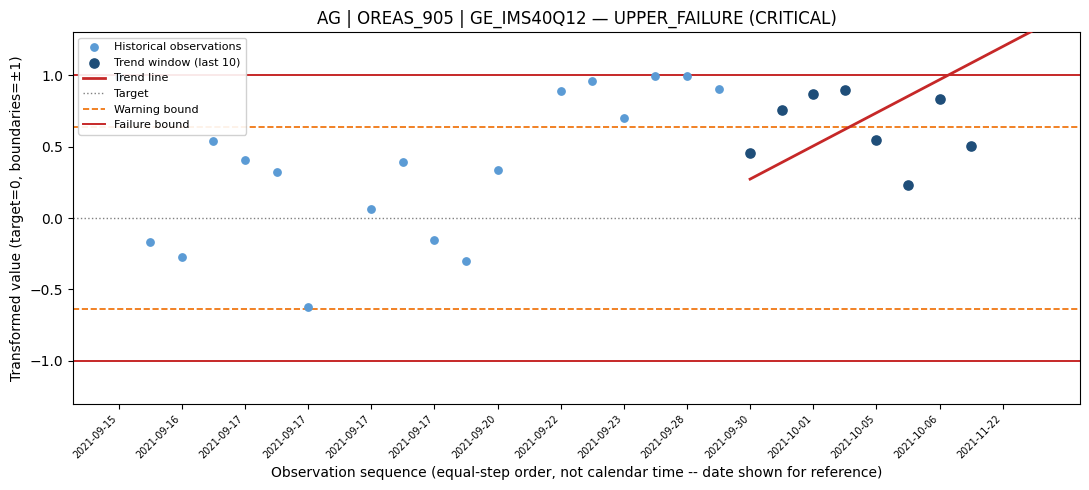

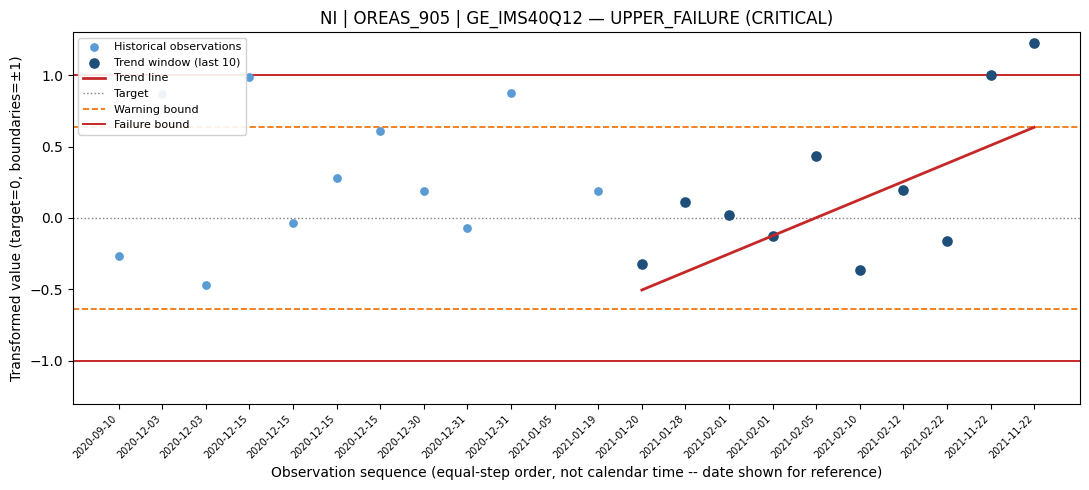

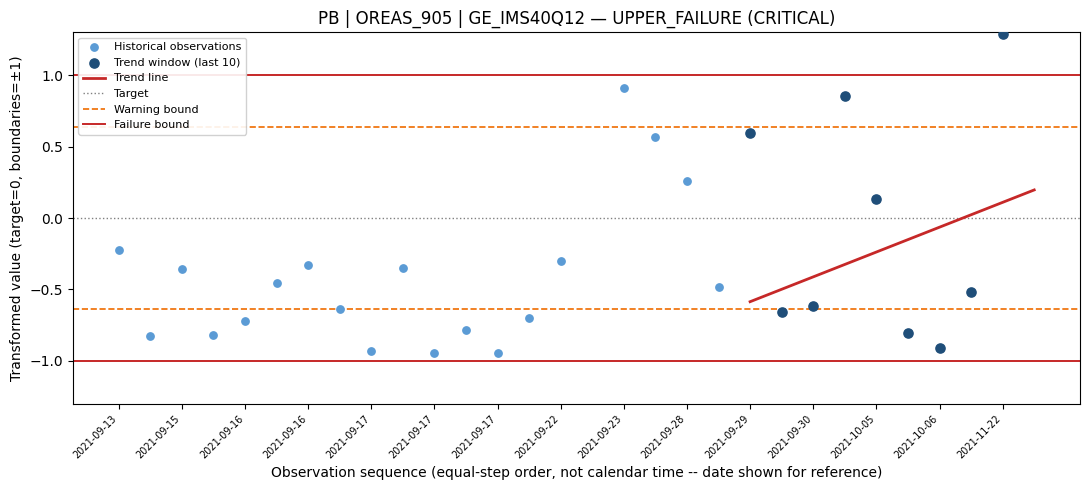

In [20]:
# Auto-plot this job's flagged analytes (capped at MAX_AUTO_PLOTS). Note: the plot
# draws from the group's FINAL (end-of-simulation) history -- identical to
# "history as of this job" when REPORT_JOB_CODE is the most recent job, but may
# show extra later points for an older job picked above. The report table itself
# (above) is always point-in-time-correct regardless of which job is picked.
to_plot = job_flagged.head(MAX_AUTO_PLOTS)
if len(job_flagged) > MAX_AUTO_PLOTS:
    print(f"Showing the {MAX_AUTO_PLOTS} most severe (MAX_AUTO_PLOTS) of {len(job_flagged)} flagged.")

for _, _row in to_plot.iterrows():
    _mask = (
        (final_history_df["ANALYTE_CODE"] == _row["ANALYTE_CODE"]) &
        (final_history_df["STD_CODE"] == _row["STD_CODE"]) &
        (final_history_df["SCHEME_CODE"] == _row["SCHEME_CODE"])
    )
    plot_analyte_drift(final_history_df.loc[_mask], _row)
    plt.show()

## Manual drill-down

Inspect any `(ANALYTE_CODE, STD_CODE, SCHEME_CODE)` group's full final history directly, independent of any one job.

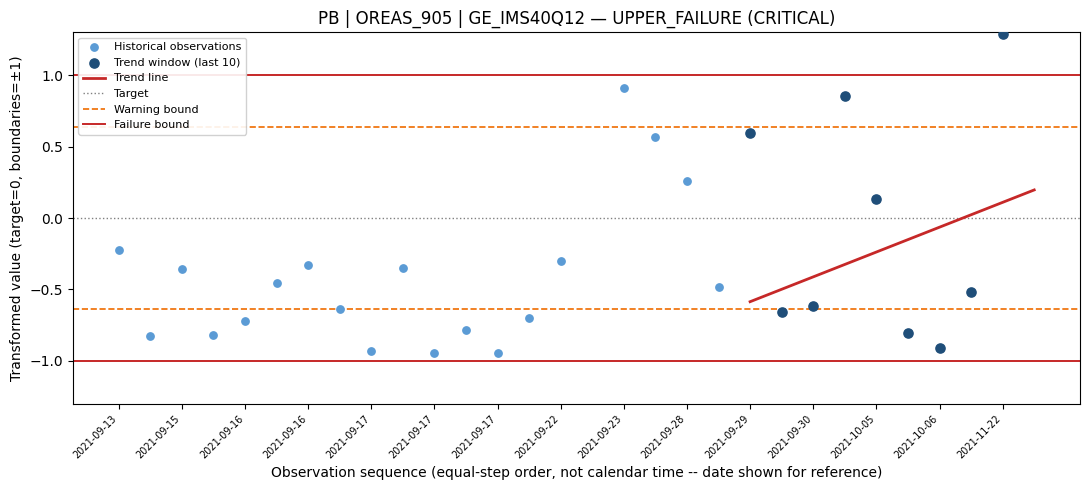

In [21]:
PICK_ANALYTE, PICK_STD_CODE, PICK_SCHEME_CODE = "PB", "OREAS_905", "GE_IMS40Q12"

_mask = (
    (final_history_df["ANALYTE_CODE"] == PICK_ANALYTE) &
    (final_history_df["STD_CODE"] == PICK_STD_CODE) &
    (final_history_df["SCHEME_CODE"] == PICK_SCHEME_CODE)
)
_group_df = final_history_df.loc[_mask]

if _group_df.empty:
    print("No history for that group -- check the codes above.")
else:
    _drift_row = run_historic_drift_detection(
        final_history_df, restrict_groups=[(PICK_ANALYTE, PICK_STD_CODE, PICK_SCHEME_CODE)]
    ).iloc[0]
    plot_analyte_drift(_group_df, _drift_row)
    plt.show()

## Notes / open questions for Datamine

Mirrors the style of `notebooks/SRMS_LOGIC.md` -- these are documented assumptions
that should get domain sign-off before this feeds any operational decision:

- **Grouping**: `(ANALYTE_CODE, STD_CODE, SCHEME_CODE)` is treated as one independent
  time series. `STD_LOT_CODE` is carried through as metadata only; `JOB_CODE` drives
  the simulation order but is not part of the grouping key. Confirm `STD_CODE` (not
  `STD_LOT_CODE`) is the correct physical-standard identity field.
- **Excluded `STD_CODE`s**: blank, `"Sample"`, `"TSV_BLANK"` are dropped before history
  is ever built (same list as `SRMS_LOGIC.md`). Confirm this list is complete.
- **Trend/plot time basis**: equal-step observation order, not elapsed calendar time --
  a lab-downtime gap (jobs are irregular; a lab can go quiet for two weeks) no longer
  shrinks the calculated slope. `TREND_SLOPE` is in transformed units per OBSERVATION,
  not per day. `MAX_HISTORY_AGE_DAYS` (if enabled) still operates on real calendar
  dates -- only the trend/plot representation changed.
- **Job-by-job simulation**: each job is evaluated using only history known strictly
  before it arrived, so the per-job report table is always point-in-time-correct. The
  supplementary drill-down/report *plots* draw from the group's final (end-of-run)
  history, which can include later points if an older job is inspected -- a documented
  simplification, not an error in the report table itself.
- **Ignored failures**: `IgnoredUpperFailure`/`IgnoredLowerFailure` are still classified
  as real point breaches by `classify_point_status()` -- the source `STANDARD_STATUS` is
  kept as a separate reference column, not used to suppress the signal.
- **Minimum history**: `MIN_HISTORY_POINT=3` / `MIN_HISTORY_TREND=6` were chosen from the
  observed group-size distribution in this export (58% of groups have <20 observations
  ever). Revisit once real drift outcomes have been reviewed by a domain expert.
- **History window**: `MAX_HISTORY_PER_ANALYTE=30`, no age cutoff by default (a new
  physical standard lot already starts a fresh `STD_CODE` group).
- **Failure-drift escalation threshold** (`TREND_PROGRESS_MIN_FOR_FAILURE_DRIFT=0.75`):
  an operational threshold, not derived from the data -- needs domain review.
- **Changing limits/target over time**: not observed in the current export (every group
  has exactly one historical (target, min, max, warning) tuple), but the transform is
  computed per-row from that row's own limits so this degrades gracefully if a future
  export does have limit changes mid-history.